# Session 4: Convolutional Neural Networks and Filters

This notebook contains structured tasks based on Session 4 materials.

**Instructions:**
- Do NOT use a separate `.py` file. Complete all tasks directly in this notebook.
- Keep your code clear and well-commented.
- For Visulaization, please use `%matplotlib inline`
- Submit your completed notebook by uploading it to your forked repository.

### ***DO NOT UPLOAD THE DATASET TO GITHUB as it's too large***
<hr>

## Task 1: Convolutional Filters on an Image
Apply several 2D filters (Sobel X, Sobel Y, Laplacian, and Sharpen) to an image and visualize the results side by side.

**Hint:**
- Use OpenCV (`cv2.filter2D`) or NumPy to apply kernels.
- Define common kernels (Sobel, Laplacian, Sharpen).
- Use `matplotlib.pyplot` to plot the original and filtered images.

In [3]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
%matplotlib inline

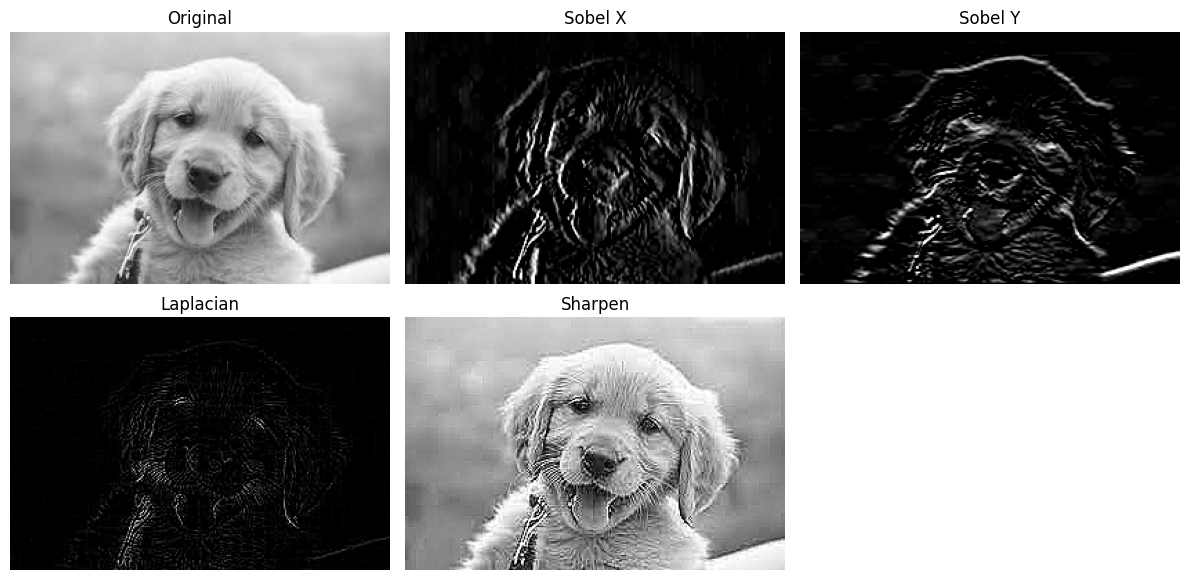

In [4]:
# TODO: Load an image (use OpenCV or matplotlib)
img = cv.imread("dogBGR.jpg", cv.IMREAD_GRAYSCALE)
# TODO: Convert to grayscale
# TODO: Define Sobel, Laplacian, and Sharpen kernels
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [0,  0,  0],
                    [1,  2,  1]])

laplacian = np.array([[0,  1, 0],
                      [1, -4, 1],
                      [0,  1, 0]])

sharpen = np.array([[0, -1,  0],
                    [-1, 5, -1],
                    [0, -1,  0]])
# TODO: Apply each filter to the image
sobel_x_img = cv.filter2D(img, -1, sobel_x)
sobel_y_img = cv.filter2D(img, -1, sobel_y)
laplacian_img = cv.filter2D(img, -1, laplacian)
sharpen_img = cv.filter2D(img, -1, sharpen)
# TODO: Plot results in a grid using matplotlib
titles = ["Original", "Sobel X", "Sobel Y", "Laplacian", "Sharpen"]
images = [img, sobel_x_img, sobel_y_img, laplacian_img, sharpen_img]
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Task 2: Build a Simple CNN on FashionMNIST
Construct and train a small Convolutional Neural Network (CNN) on the FashionMNIST dataset.

**Hint:**
- Use `torchvision.datasets.FashionMNIST` for loading data.
- Define a small CNN with `nn.Conv2d`, `nn.ReLU`, `nn.MaxPool2d`, and `nn.Linear`.
- Train for a few epochs using an optimizer (e.g., Adam) and loss function (e.g., CrossEntropyLoss).
- Print training accuracy after each epoch.

In [7]:
# TODO: Import torch, torchvision, and related libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
# TODO: Load FashionMNIST dataset with transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   
])

train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
# TODO: Define a simple CNN class with one conv layer and one fc layer
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  
        self.pool = nn.MaxPool2d(2, 2)                            
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7) 
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
# TODO: Set up optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
# TODO: Implement a short training loop (2-3 epochs)
epochs = 3
for epoch in range(epochs):
    model.train()
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Training Accuracy: {acc:.2f}%")


Epoch [1/3], Loss: 0.2847, Training Accuracy: 84.71%
Epoch [2/3], Loss: 0.3957, Training Accuracy: 90.38%
Epoch [3/3], Loss: 0.0700, Training Accuracy: 91.90%


## Task 3: Visualize Feature Maps
Visualize feature maps produced by the first convolutional layer of your CNN.

**Hint:**
- Take a single image from the test set.
- Pass it through the first convolutional layer (`net.conv1`).
- Convert the output to NumPy and plot several channels as images.

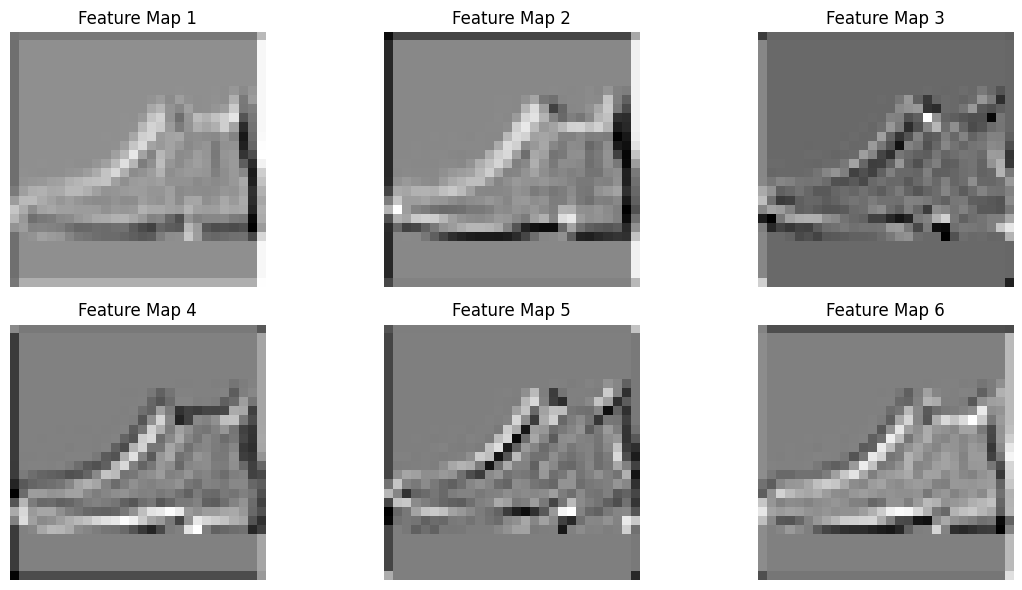

In [8]:
# TODO: Take one test image
images, labels = next(iter(test_loader))
image = images[0].unsqueeze(0).to(device) 
# TODO: Forward pass through the first convolutional layer
with torch.no_grad():
    feature_maps = model.conv1(image) 
# TODO: Convert feature maps to NumPy array
feature_maps = feature_maps.squeeze(0).cpu().numpy() 
# TODO: Plot the first few feature maps in a grid
plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(feature_maps[i], cmap="gray")
    plt.title(f"Feature Map {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Task 4: Haar Cascade Face Detection

Apply Haar Cascade classifiers for basic object detection (faces).

**Hint:**
- Use `cv2.CascadeClassifier` with a pre-trained XML file (e.g., `haarcascade_frontalface_default.xml`).
- Convert the input image to grayscale before detection.
- Use `detectMultiScale` to get bounding boxes.
- Draw rectangles on detected faces with `cv2.rectangle`.
- Visualize with Matplotlib.


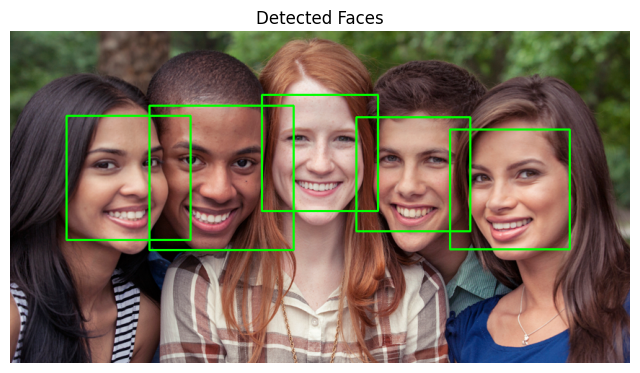

In [4]:
# TODO: Load an image containing a face
img = cv.imread("sample.png")
# TODO: Convert to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
# TODO: Load Haar Cascade XML (frontal face) || cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
face_cascade = cv.CascadeClassifier(cv.data.haarcascades + "haarcascade_frontalface_default.xml")
# TODO: Apply detectMultiScale to find faces
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
# TODO: Draw bounding boxes on the original image
for (x, y, w, h) in faces:
    cv.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
# TODO: Display results with matplotlib
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("Detected Faces")
plt.axis("off")
plt.show()
